In [7]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from water_sim import (
    generate_polyhedron,
    compute_vertex_normals_and_volume,
    step_simulation,
    step_forward_euler
    )
    
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

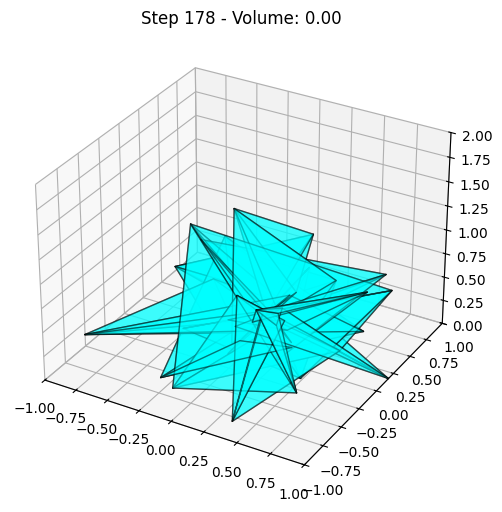

In [ ]:
# --- Initialization ---
n_verts = 50
radius = 0.1
x, faces, neighbours = generate_polyhedron(n_vertices=n_verts, radius=radius) #

# Drop from Z=1 (Center is at 0, so we add 2 to clear the floor)
x[:, 2] += 0.3
v = np.zeros_like(x)

# Calculate the 'ideal' volume to maintain
_, V_initial = compute_vertex_normals_and_volume(x, faces) #

dt = 0.001
num_steps = 1000

# --- Plotting Setup ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for s in range(num_steps):
    # Update Physics
    v, x = step_simulation(
            v,
            x,
            faces,
            neighbours,
            V_initial,
            dt,
            method="verlet",
            g=[0, 0, -9.81],
            gamma=0.2,
            mu=0.3,
            eta=0.05,
            k_v=200.0,
            density=1.0,
            boundary_alpha=0.5,
            friction_coeff=0.5,
            receding_angle=np.deg2rad(70.0),
            advancing_angle=np.deg2rad(95.0),
            adhesion_dist=0.05,
            max_internal_accel=200.0,
            max_internal_substeps=8,
            volume_stiffness=0.5,
            rho=0.1,
    )
    
    # Visualization
    ax.clear()
    
    # Create triangle mesh for plotting
    poly = Poly3DCollection(x[faces], alpha=0.5, edgecolor='k', facecolors='cyan')
    ax.add_collection3d(poly)
    
    # Fix the viewing window
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(0, 2)
    ax.set_title(f"Step {s} - Volume: {V_initial:.2f}")
    
    # Refresh the notebook display
    display.clear_output(wait=True)
    display.display(plt.gcf())
    
plt.close() # Prevents extra static plot from showing